# Esperimento  sull'agent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [21]:
RESULT_TOT="../data/training_dataset/results/results_combined_new_model_name_wo_edge.csv"
colors = cm.tab10.colors
df = pd.read_csv(RESULT_TOT)
df['model'].unique()

<ArrowStringArray>
[                   'qwen-chat-agent-4-v2',
                          'chat-qwen-base',
                       'qwen-chat-agent-6',
                        'qwen-extractor-3',
                        'qwen-extractor-4',
                        'qwen-extractor-2',
    'qwen-chat-extractor-tuned-lora-16-v1',
                    'qwen-chat-agent-5-v1',
                       'qwen-chat-agent-7',
          'qwen-chat-agent-8-wo-embedding',
                      'qwen-chat-agent-12',
                       'qwen-chat-agent-9',
                'qwen-extractor-5-lora-32',
              'qwen-extractor-6-embedding',
 'qwen_chat_agent_13_dense_reward_30_step',
         'qwen_chat_agent_13_dense_reward',
                     'qwen_chat_agent_sft',
                      'qwen_extractor_sft',
                       'qwen_combined_sft',
                      'qwen_combined_grpo']
Length: 20, dtype: str

In [22]:
target ='base|qwen_combined_sft|qwen_combined_grpo'
models = list(df[df['model'].str.contains(target)]['model'].unique())
labels = ['qwen-base','SFT','GRPO']
models

['chat-qwen-base', 'qwen_combined_sft', 'qwen_combined_grpo']

0.46 	+-0.0203571170187945
0.538 	+-0.02110520399558754
0.914 	+-0.01283089553025661


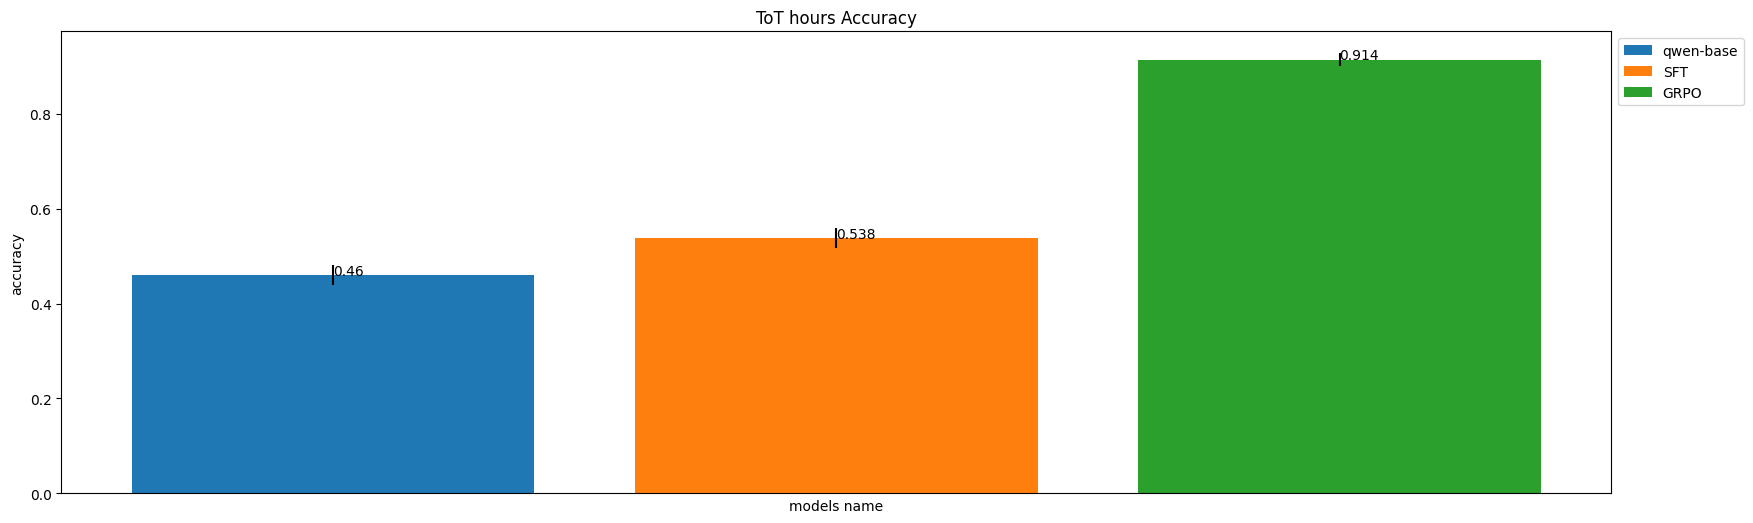

In [23]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

media_group = []
CI_group = []


for model in models:
    g = df.loc[(df['model'] == model)]
    acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
      )                                                                                                                                                                                                                                                                                                      
    # effective n = total field evaluations (not number of rows)                                                                                          
    n = g['n_relevant_fields'].sum()
    # intervallo di confidenza al 90 %
    CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
    media_group.append(acc_media)
    CI_group.append(CI)


for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")

plt.figure(figsize=(20,6))
plt.bar(labels, media_group, yerr=CI_group, color=colors , label=labels)
add_labels(models,media_group)
plt.title("ToT hours Accuracy")
plt.xlabel("models name")
plt.ylabel("accuracy")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

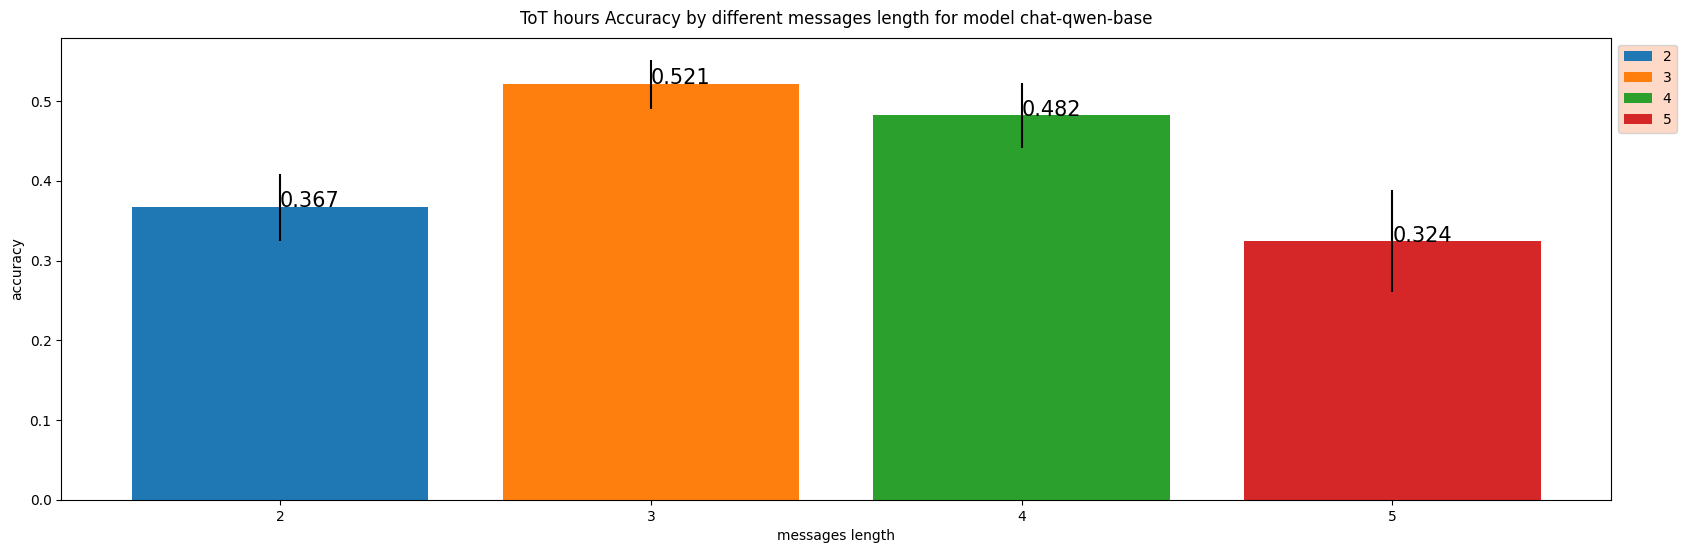

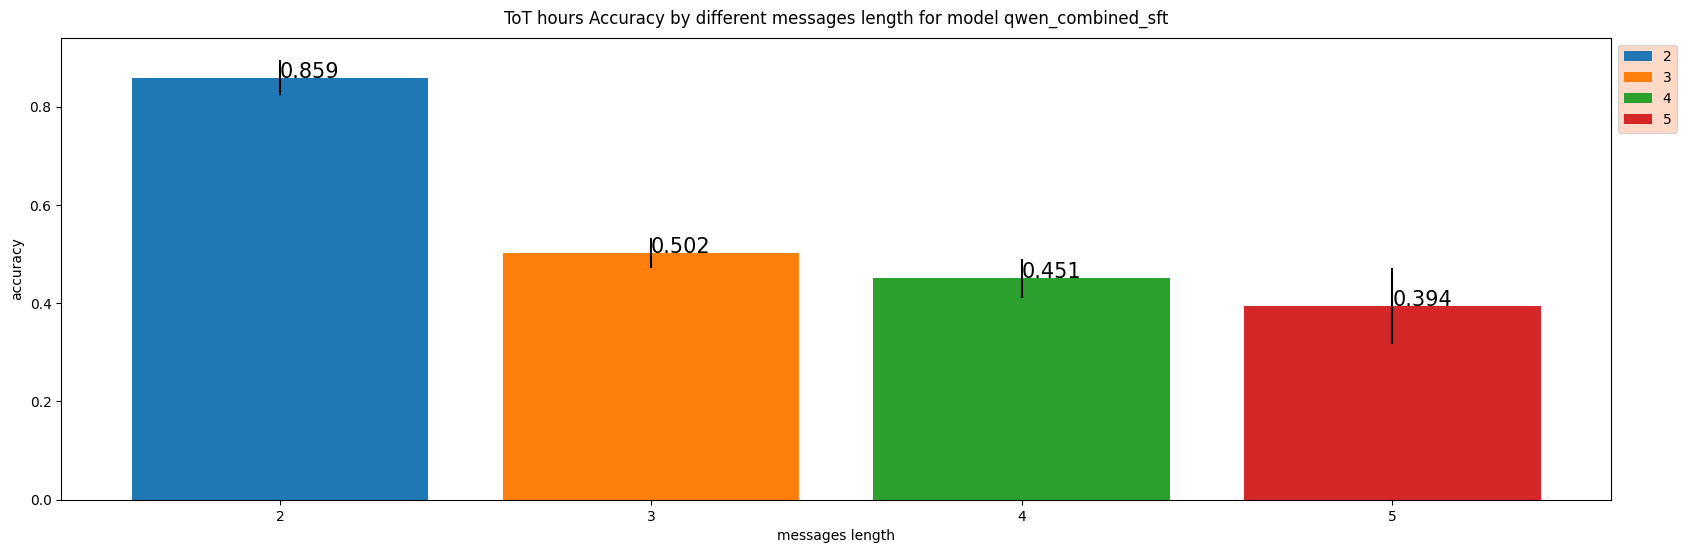

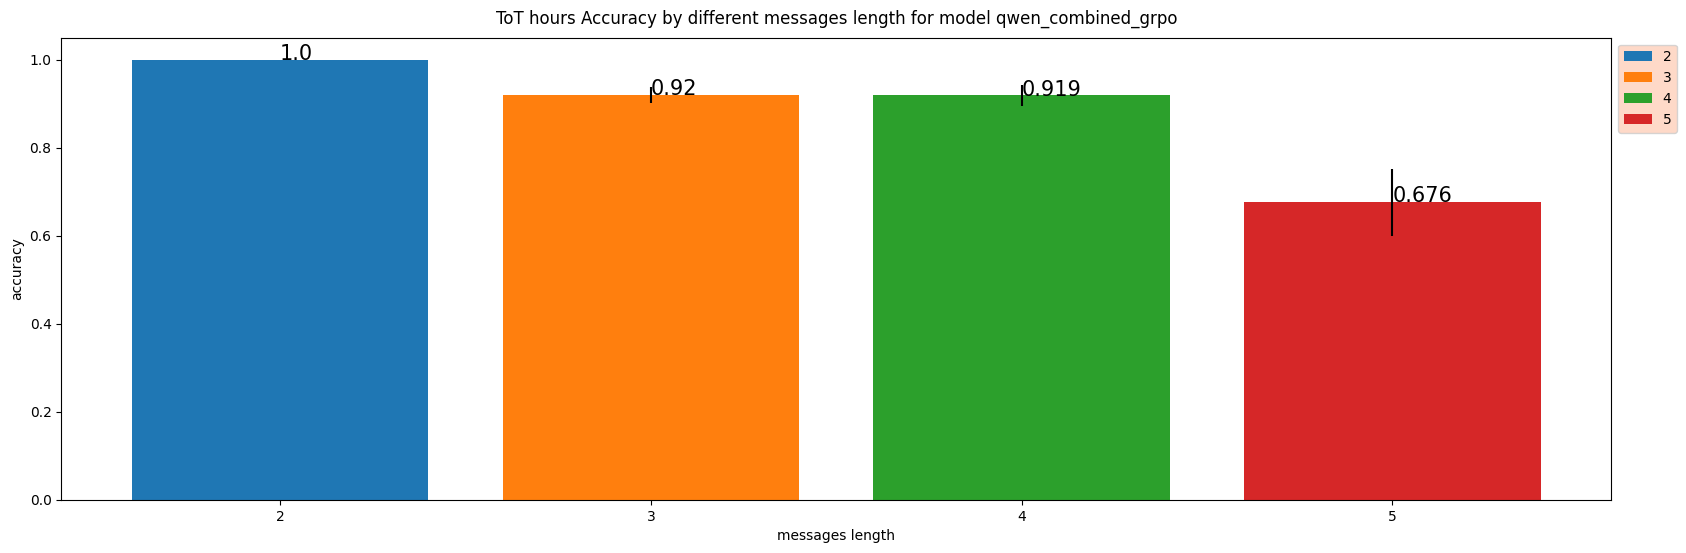

In [24]:
# accuracy a diversi livelli di lunghezza della lista messaggi
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    l_msg = np.sort(df['L_MESSAGGI'].unique())
    for length_m in l_msg:
        g = df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)]
        
        acc_media = round(                                                                                                                                    
          (g['tot_acc'] * g['n_relevant_fields']).sum() / g['n_relevant_fields'].sum(),                                                                     
          3                                                                                                                                                 
        )                                                                                                                                                                                                                                                                                                      
        # effective n = total field evaluations (not number of rows)                                                                                          
        n = g['n_relevant_fields'].sum()
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(l_msg,media_group, yerr=CI_group, label=l_msg, color=colors)
    add_labels(l_msg,media_group)
    plt.title(f"ToT hours Accuracy by different messages length for model {model}", pad=10)
    plt.xlabel("messages length")
    plt.xticks(l_msg)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


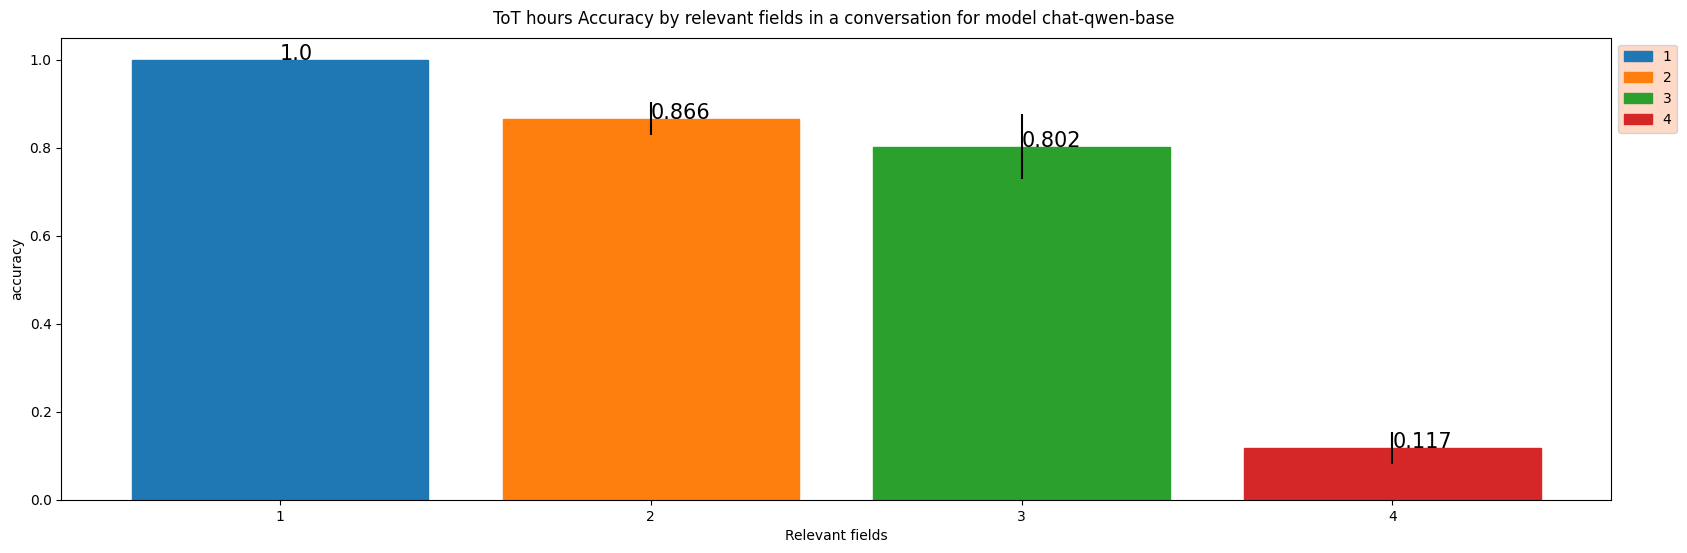

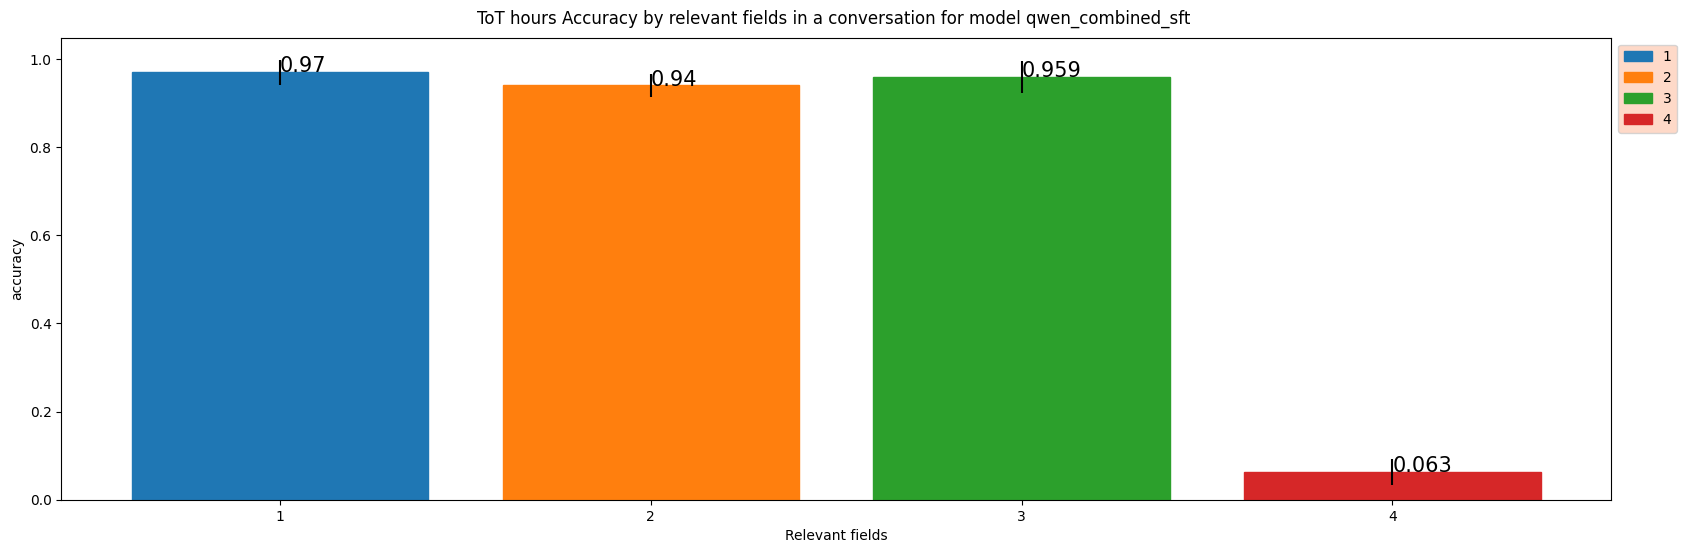

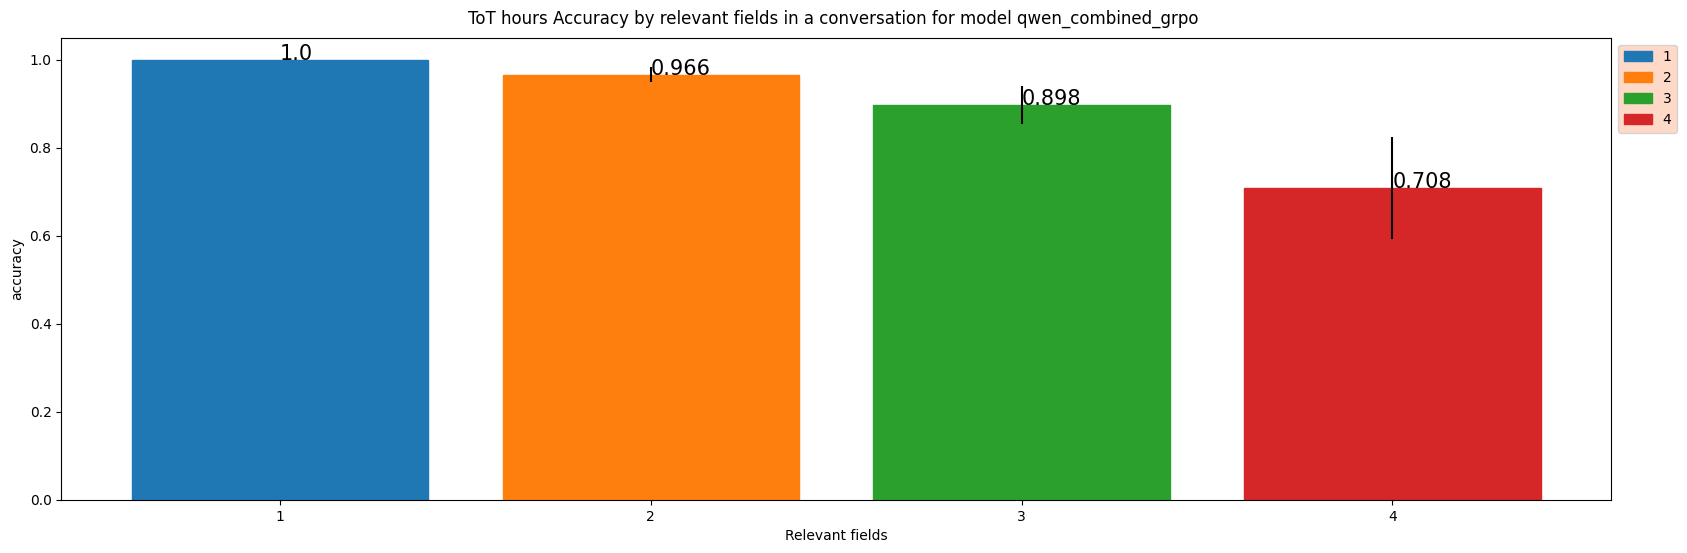

In [25]:
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i],size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())

for model in models:
    media_group = []
    CI_group = []
    n_fields = np.sort(df['n_relevant_fields'].unique())[1:]
    for n_field in n_fields:
        acc_media = round(df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)]['tot_acc'].mean(),3)
        n = len(df.loc[(df['model'] == model)  & (df['n_relevant_fields'] == n_field)])
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    plt.figure(figsize=(20,6))
    plt.bar(n_fields,media_group, yerr=CI_group, label=n_fields, color=colors, edgecolor=colors)
    add_labels(n_fields,media_group)
    plt.title(f"ToT hours Accuracy by relevant fields in a conversation for model {model} ", pad=10)
    plt.xlabel("Relevant fields")
    plt.xticks(n_fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")

In [33]:
df.columns

Index(['model', 'language', 'messaggi', 'ore_ordinarie_true',
       'ore_straordinarie_true', 'ore_viaggio_true', 'note_true',
       'inefficiency_true', 'inefficiency_note_true', 'chat_context',
       'function_calls', 'push_data_response', 'ore_ordinarie_acc',
       'ore_straordinarie_acc', 'ore_viaggio_acc', 'inefficiency_acc',
       'tot_acc', 'ore_ordinarie_predict', 'ore_straordinarie_predict',
       'ore_viaggio_predict', 'note_predict', 'inefficiency_predict',
       'inefficiency_note_predict', 'REF_INDICE', 'L_MESSAGGI', 'TYPE_EVAL',
       'count_function_calls', 'failure_reason',
       'sentence_similarity_score_note',
       'sentence_similarity_score_inefficiency', 'n_relevant_fields'],
      dtype='str')

0.499 	+-0.03383306145377662
0.477 	+-0.03379731471363948
0.536 	+-0.033745319700545846
0.262 	+-0.029754385702412324
0.281 	+-0.030415136298102444
0.851 	+-0.024095174513040465
0.648 	+-0.03231699689520784
0.496 	+-0.03383204644264757
0.569 	+-0.033509421484336166
0.337 	+-0.031984817458329186
0.545 	+-0.03369582634372488
0.718 	+-0.03044801172107134
0.913 	+-0.01907072382563133
0.92 	+-0.018357395684337596
0.945 	+-0.01542657130270238
0.842 	+-0.024680658967555103
0.607 	+-0.03304933935960897
0.813 	+-0.026383854173350207


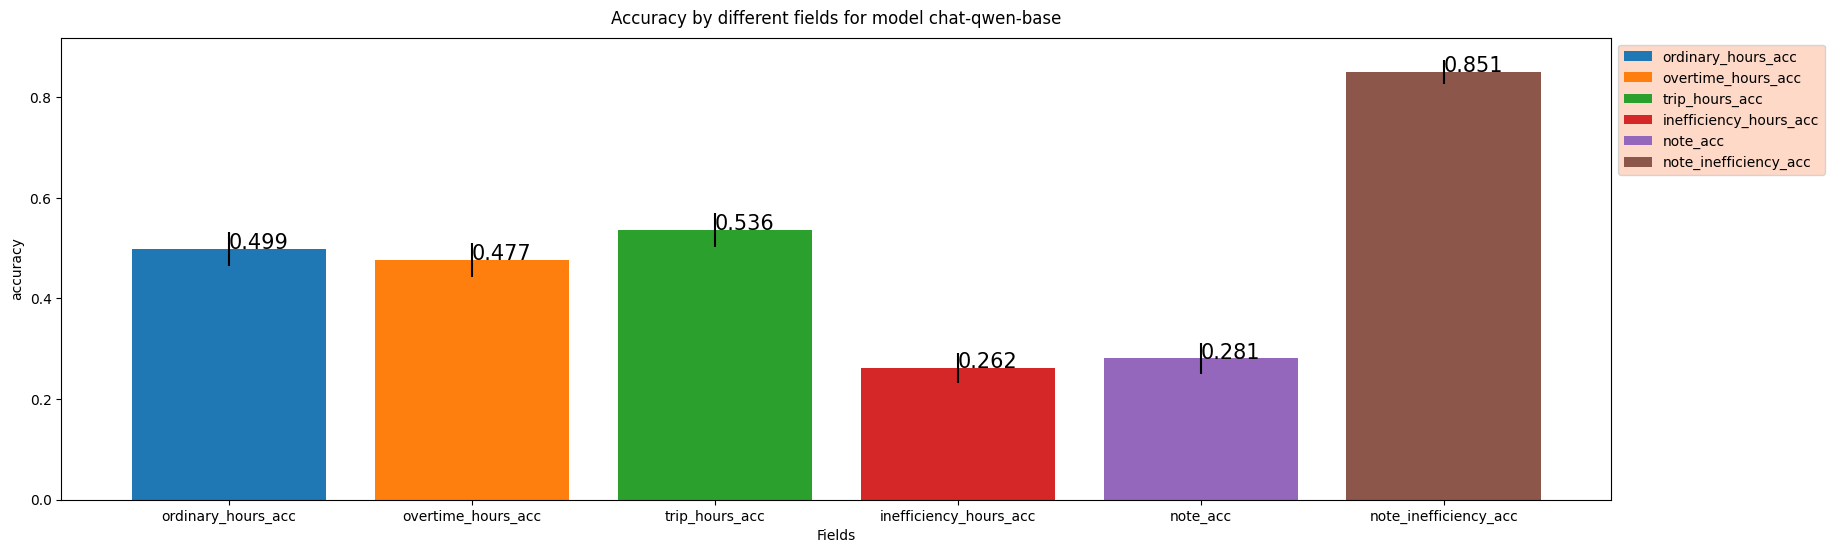

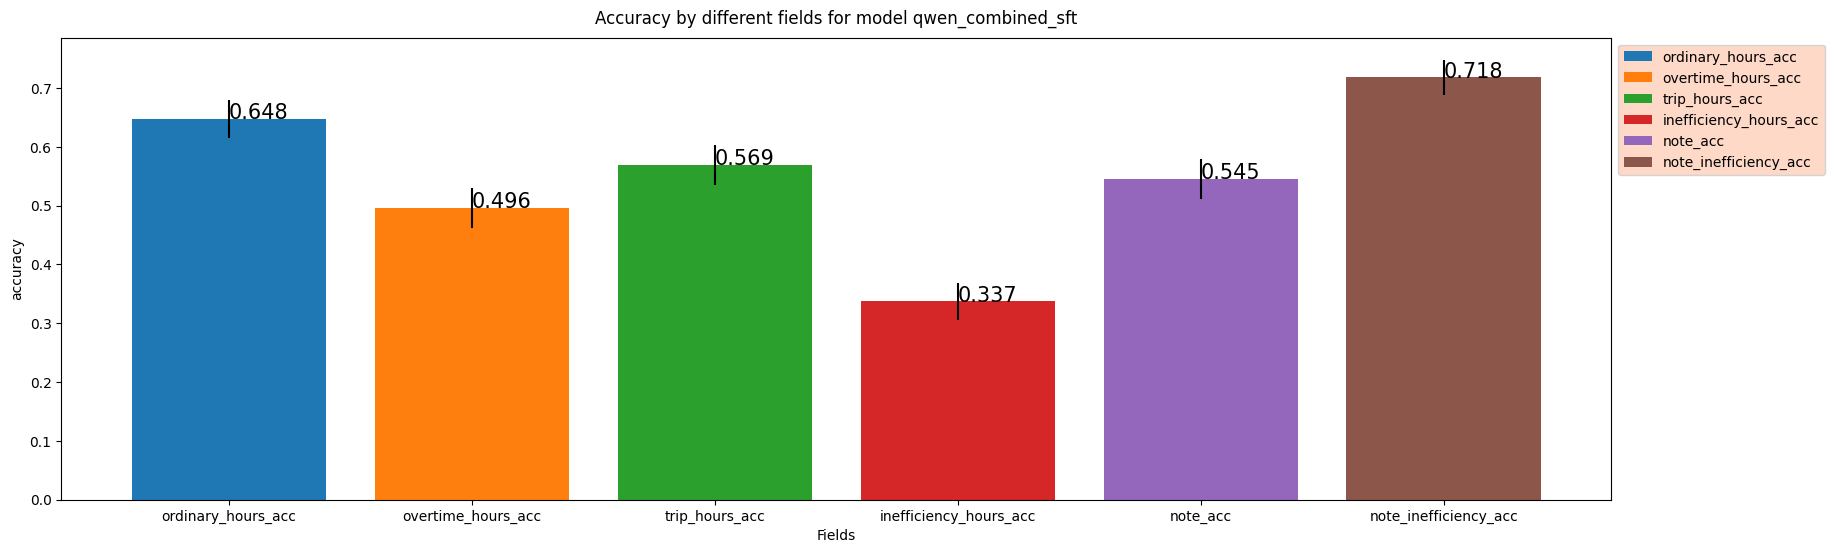

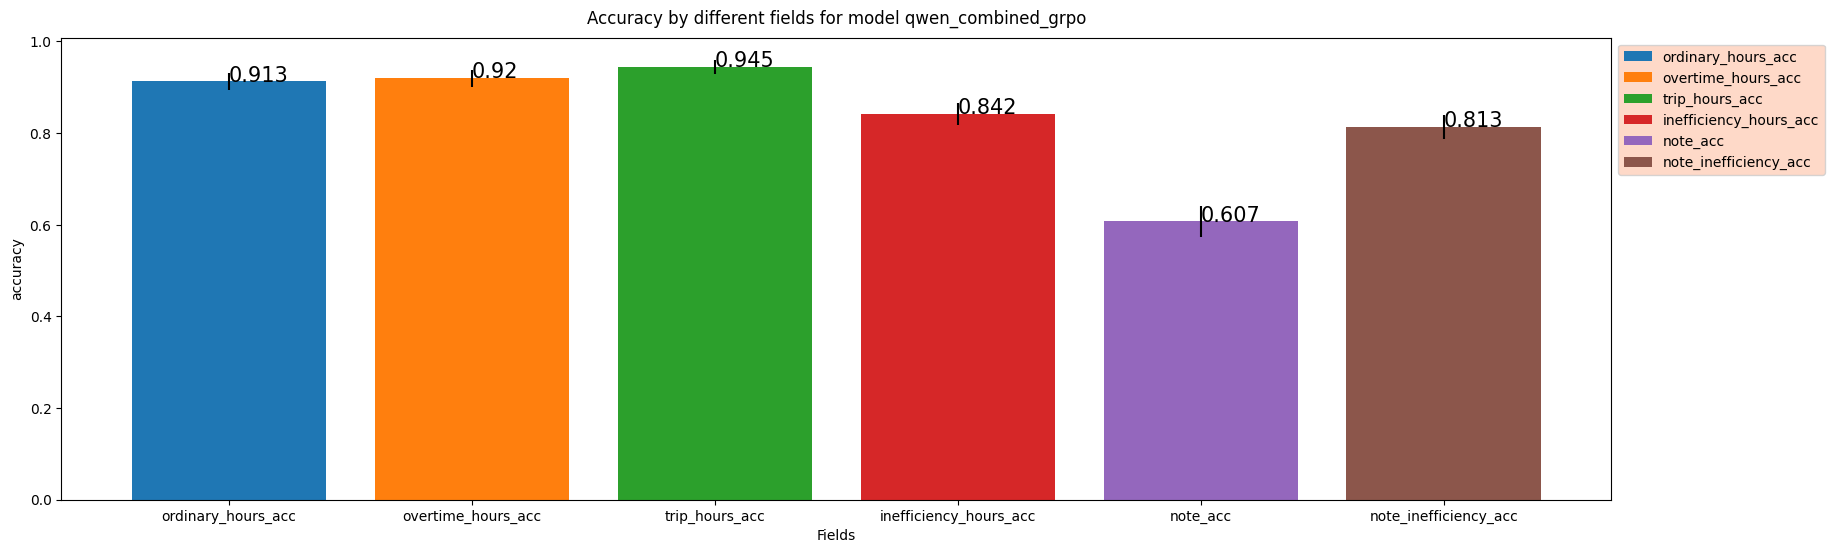

In [28]:
# chart per il display tot per ogni misurazione
# accuracy a tipi di schema
def add_labels(labels, vals):
    for i,x_label in enumerate(labels):
        plt.text(x_label,vals[i], vals[i], size=15)

models = list(df[df['model'].str.contains(target)]['model'].unique())


for model in models:
    media_group = []
    CI_group = []
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    fields=['ordinary_hours_acc', 'overtime_hours_acc', 'trip_hours_acc','inefficiency_hours_acc','note_acc','note_inefficiency_acc']
    for column in columns:
            
        acc_media = round(df.loc[(df['model'] == model)][column].mean(),3)
        n = len(df.loc[(df['model'] == model)])
        # intervallo di confidenza al 90 %
        CI = 1.645 * np.sqrt(acc_media * (1- acc_media) / n)
        media_group.append(acc_media)
        CI_group.append(CI)

    for media,CI in zip(media_group, CI_group):
        print(f"{media} \t+-{CI}")
    plt.figure(figsize=(20,6))
    plt.bar(fields,media_group, yerr=CI_group, label=fields, color=colors)
    add_labels(fields,media_group)
    plt.title(f"Accuracy by different fields for model {model}", pad=10)
    plt.xlabel("Fields")
    plt.xticks(fields)
    plt.ylabel("accuracy")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1),frameon=True,facecolor="#fed0bb")


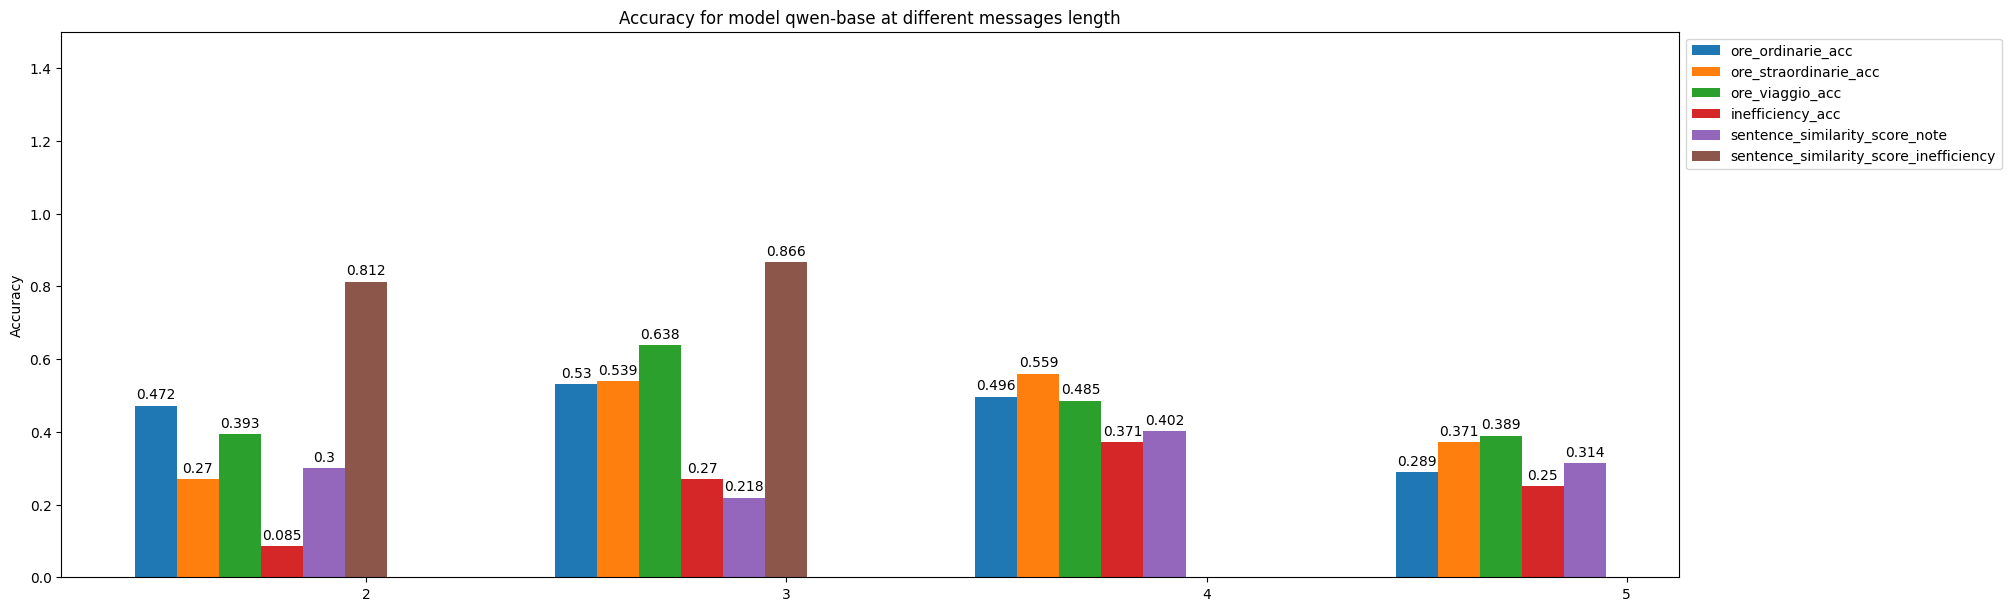

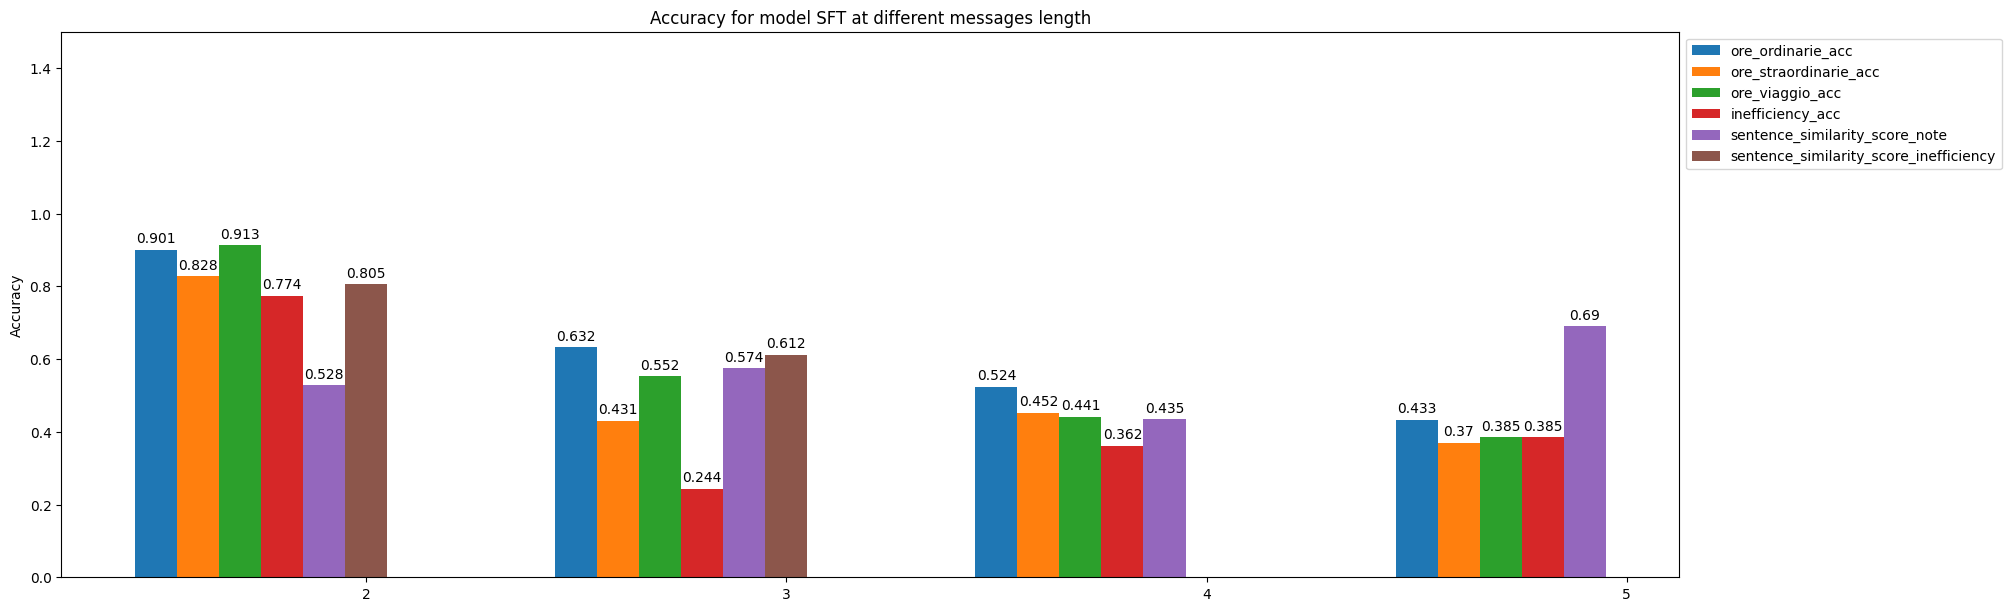

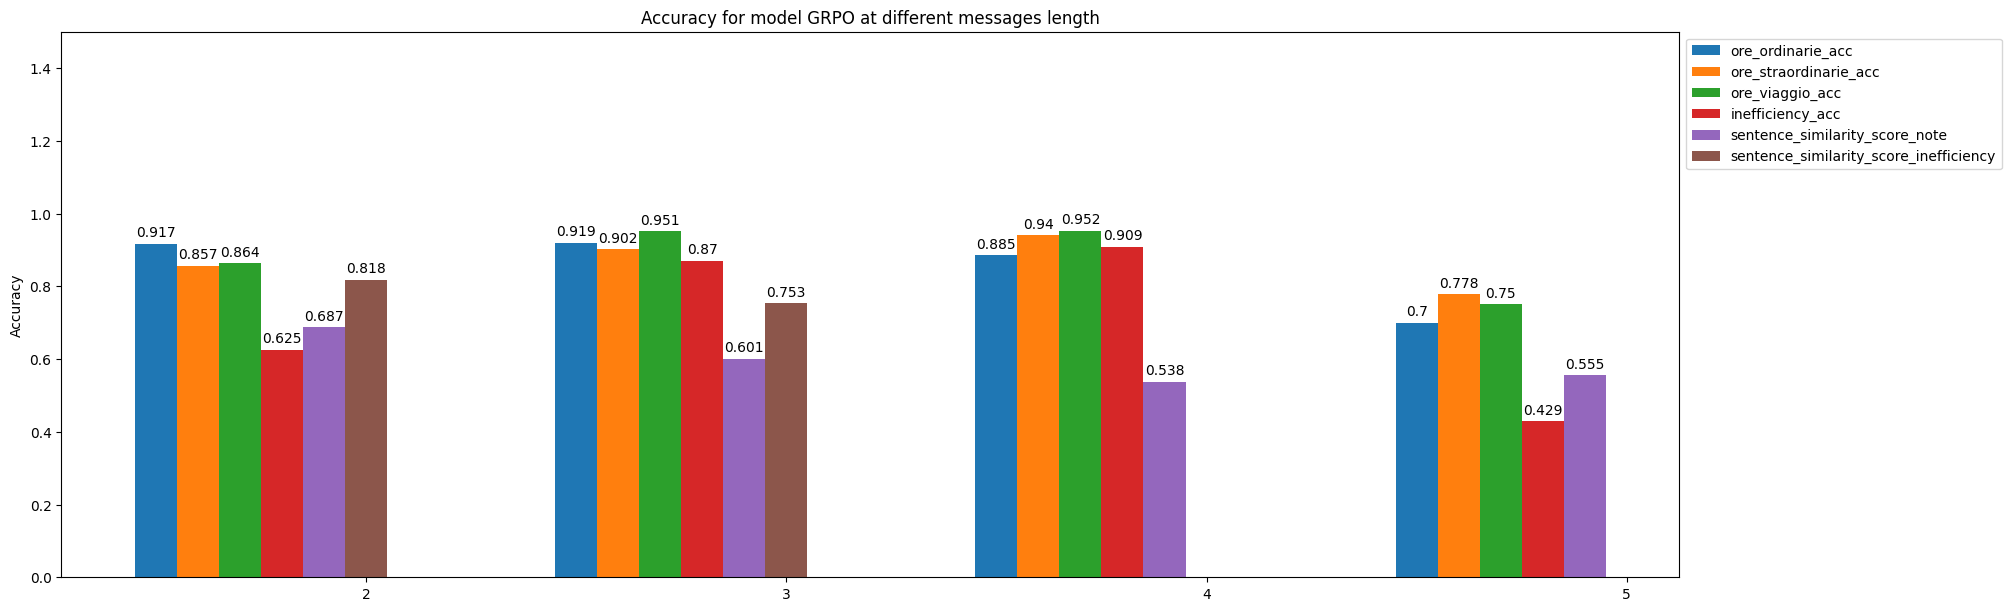

In [7]:
# chart per fare il display accuracy totale  al variare del flow


l_msg = np.sort(df['L_MESSAGGI'].unique())
for model,label in zip(models,labels):
    metric_means = {}
    columns = ['ore_ordinarie_acc', 'ore_straordinarie_acc', 'ore_viaggio_acc','inefficiency_acc','sentence_similarity_score_note','sentence_similarity_score_inefficiency']
    # init il dict
    for column in columns:
        metric_means[column] = ()

    for length_m in l_msg:
        for column in columns:
            if column == 'sentence_similarity_score_inefficiency' or column == 'sentence_similarity_score_note':
                ris = (round(df.loc[(df['model'] == model) & (df[column].isna() != True) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
            else:
                ris = (round(df.loc[(df['model'] == model) & (df['L_MESSAGGI'] == length_m)][column].mean(),3),)
                metric_means[column] += ris
    
    x = np.arange(len(l_msg))  # the label locations
    width = 0.10  # the width of the bars
    multiplier = 0
    fig, ax = plt.subplots(figsize=(20,6), layout='constrained')
    for attribute, measurement in metric_means.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        
        # inseriamo l'accuracy media
        """ if attribute == 'ore_viaggio_acc':
            x_pos = x + offset
            for x in x_pos:
                ax.text(x, 1.1,'prova') """

        multiplier += 1
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy for model {label} at different messages length')
    ax.set_xticks(x + offset, l_msg)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    ax.set_ylim(0, 1.5)

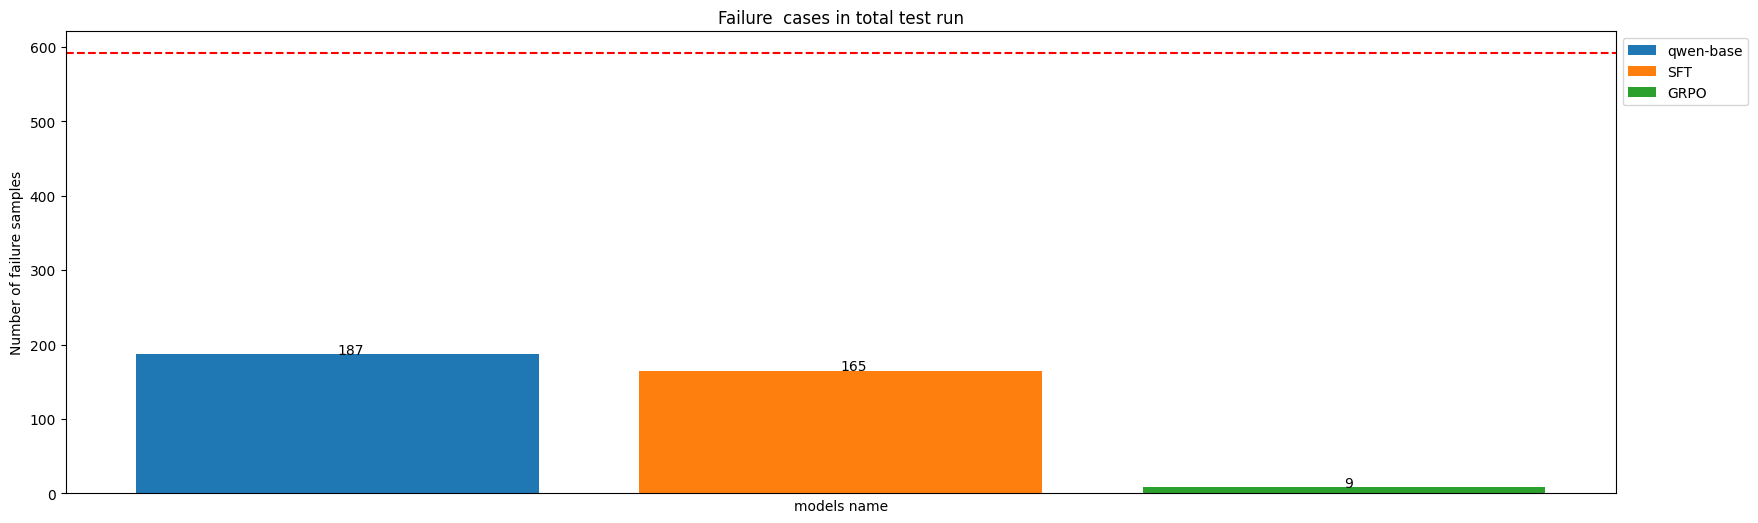

In [27]:
def add_labels(labels, vals):
    for i in range(len(labels)):
        plt.text(i,vals[i], vals[i])

dict_results = {}
for model in models:
    dict_results[model] = df.loc[(df['model'] == model) ]['failure_reason'].notna().sum() 

data = dict_results.values()
#labels = dict_results.keys()

plt.figure(figsize=(20,6))
plt.bar(labels, data, color=colors, label=labels)
add_labels(labels,list(data))
plt.axhline(y=len(df.loc[df['model'] == models[0]]), color='red', linestyle='--', linewidth=1.5)
plt.title("Failure  cases in total test run")
plt.xlabel("models name")
plt.ylabel("Number of failure samples")
plt.xticks([])
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))

## tipi di failure pie charts

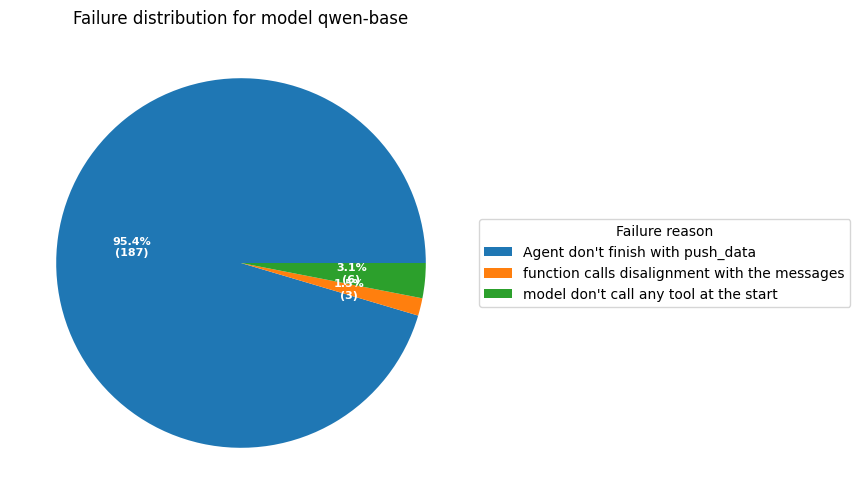

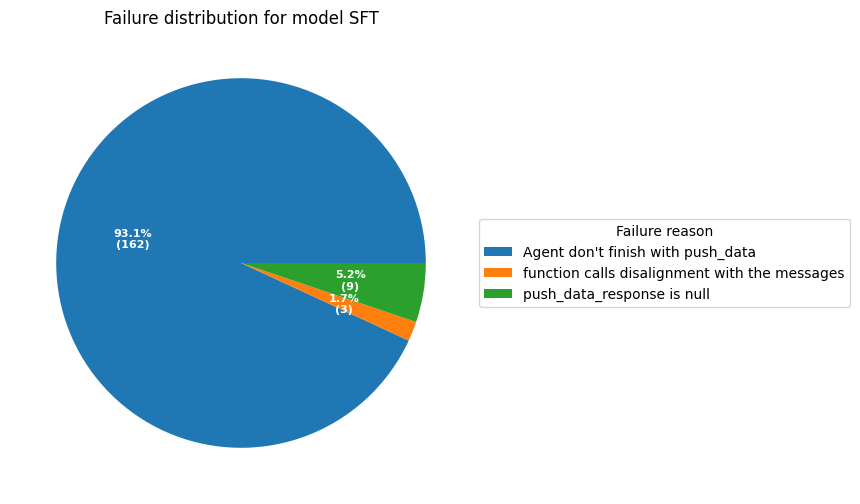

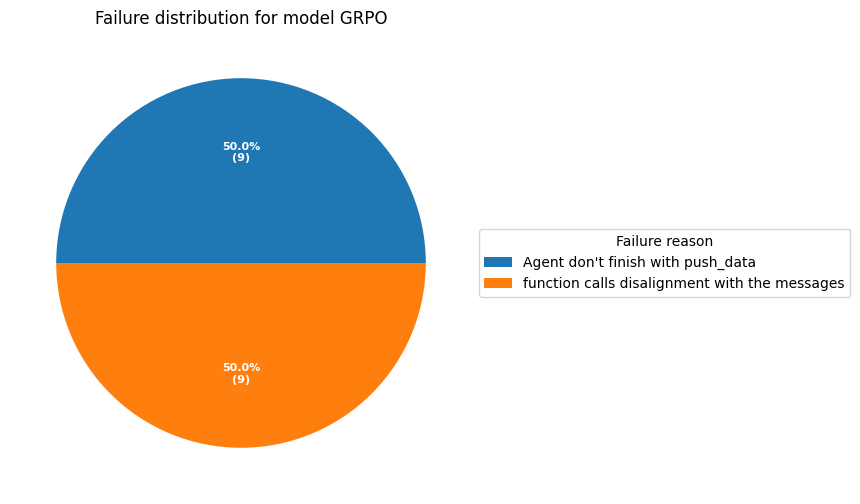

In [8]:
# pei chart sulle tipologie di failure

for model,label in zip(models,labels):
    fig, ax = plt.subplots(figsize=(20, 6), subplot_kw=dict(aspect="equal"))


    def func(pct,all):
        absolute = int(np.round(pct/100.*np.sum(all)))
        return f"{pct:.1f}%\n({absolute})"

    dict_results = dict(df.loc[df['model'] == model].groupby(['failure_reason'])['REF_INDICE'].count())
    data = dict_results.values()
    labels = dict_results.keys()
    wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct,list(data)),
                                      textprops=dict(color="w"))

    ax.legend(wedges,labels,
              title="Failure reason",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

    plt.setp(autotexts, size=8, weight="bold")

    ax.set_title(f"Failure distribution for model {label}")
    plt.show()